X Shape : (6537, 30, 132)
y Shape : (6537,)

Training Samples : 5229
Testing Samples : 1308


c:\Users\ADITI RAJ\Desktop\fall detection\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        50,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,393 (247.63 KB)

 Trainable params: 63,393 (247.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.7793 - loss: 0.4915 - val_accuracy: 0.8489 - val_loss: 0.3485
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8625 - loss: 0.3359 - val_accuracy: 0.8117 - val_loss: 0.3560
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.8958 - loss: 0.2754 - val_accuracy: 0.8547 - val_loss: 0.3536
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9166 - loss: 0.2298 - val_accuracy: 0.8987 - val_loss: 0.2497
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9350 - loss: 0.1928 - val_accuracy: 0.9484 - val_loss: 0.1507
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.9407 - loss: 0.1667 - val_accuracy: 0.9226 - val_loss: 0.1930
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9266 - loss: 0.1944 - val_accuracy: 0.9254 - val_loss: 0.1827
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9429 - loss: 0.1614 - val_acc

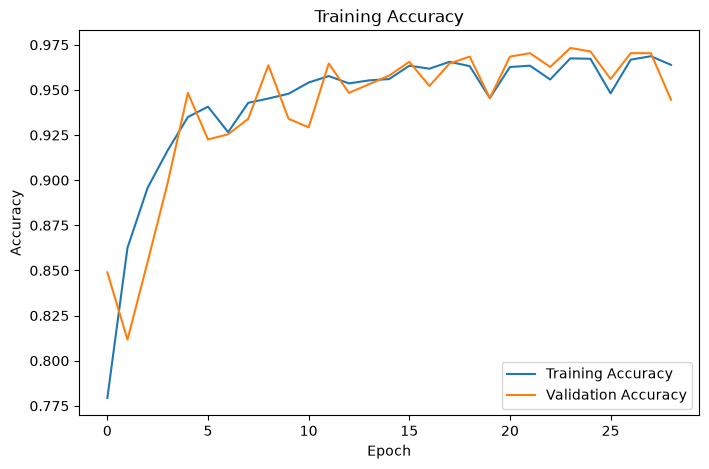

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ====================================
# CREATE MODEL FOLDER
# ====================================

os.makedirs("models", exist_ok=True)

# ====================================
# LOAD DATA
# ====================================

X = np.load("processed_data/X.npy")
y = np.load("processed_data/y.npy")

print("X Shape :", X.shape)
print("y Shape :", y.shape)

# ====================================
# TRAIN TEST SPLIT
# ====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# ====================================
# BUILD LSTM MODEL
# ====================================

model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(30, 132),
        return_sequences=True
    )
)

model.add(Dropout(0.3))

model.add(LSTM(32))

model.add(Dropout(0.3))

model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

# ====================================
# COMPILE
# ====================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ====================================
# EARLY STOPPING
# ====================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# ====================================
# TRAIN
# ====================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

# ====================================
# SAVE MODEL
# ====================================

model.save("models/fall_model.keras")

print("\nModel Saved Successfully!")

# ====================================
# TEST
# ====================================

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", accuracy)

# ====================================
# PREDICTIONS
# ====================================

predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print("\nClassification Report\n")

print(classification_report(
    y_test,
    predictions
))

print("\nConfusion Matrix\n")

print(confusion_matrix(
    y_test,
    predictions
))

# ====================================
# PLOT
# ====================================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()

plt.show()

In [2]:
import numpy as np
from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ===========================
# LOAD MODEL
# ===========================

model = load_model("models/fall_model.keras")

# ===========================
# LOAD TEST DATA
# ===========================

X = np.load("processed_data/X.npy")
y = np.load("processed_data/y.npy")

# ===========================
# MAKE PREDICTIONS
# ===========================

pred = model.predict(X, verbose=0)

pred = (pred > 0.5).astype(int).flatten()

# ===========================
# CALCULATE METRICS
# ===========================

accuracy = accuracy_score(y, pred)
precision = precision_score(y, pred)
recall = recall_score(y, pred)
f1 = f1_score(y, pred)

print("\n========== MODEL PERFORMANCE ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(
    y,
    pred,
    target_names=["Normal", "Falling"]
))

print("\n========== CONFUSION MATRIX ==========")
print(confusion_matrix(y, pred))


========== MODEL PERFORMANCE ==========
Accuracy : 0.9686
Precision: 0.9988
Recall   : 0.8921
F1 Score : 0.9425

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      4655
     Falling       1.00      0.89      0.94      1882

    accuracy                           0.97      6537
   macro avg       0.98      0.95      0.96      6537
weighted avg       0.97      0.97      0.97      6537


========== CONFUSION MATRIX ==========
[[4653    2]
 [ 203 1679]]
